In [152]:
import pandas as pd
from sklearn import linear_model
import numpy as np
from sklearn.model_selection import train_test_split

In [158]:
X = pd.read_csv("../data/X_train.csv").drop(['id'], axis=1)
y = pd.read_csv("../data/y_train.csv").drop(['id'], axis=1)

# impute data with average value 
X = X.fillna(X.mean())
X = X.drop(X.loc[:, X.var()<0.01].columns, axis=1) # only use columns with variance
X_norm =(X-X.mean())/X.std() # normalise the data

# test train split
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)

In [164]:
# Feature selection with Lasso
n = 20
lasso_result = pd.DataFrame(columns=['alpha', 'R^2', '#coef'], index=range(n))
i = 0
for a in np.linspace(0,1.5,n):
    lasso = linear_model.Lasso(alpha=a)
    lasso.fit(X_train, y_train)
    
    lasso_result.loc[i, 'alpha'] = a
    lasso_result.loc[i, 'R^2'] = lasso.score(X_test, y_test)
    lasso_result.loc[i, '#coef'] = sum(abs(lasso.coef_) > 0.01)

    i+=1




C:\Users\juliu\AppData\Local\Temp/ipykernel_7912/1818698166.py:7: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  lasso.fit(X_train, y_train)
C:\Users\juliu\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:647: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\juliu\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.142e+03, tolerance: 9.180e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Use

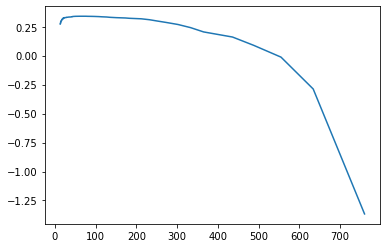

In [163]:
import matplotlib.pyplot as plt
plt.plot(lasso_result['#coef'], lasso_result['R^2'])

In [165]:
lasso_result

,alpha,R^2,#coef
0,0.0,-1.366129,760
1,0.078947,0.212818,359
2,0.157895,0.314304,226
3,0.236842,0.332788,129
4,0.315789,0.3395,84
5,0.394737,0.338533,46
6,0.473684,0.332627,33
7,0.552632,0.32794,24
8,0.631579,0.325293,22
9,0.710526,0.322759,20


In [157]:
X_train

,x0,x3,x4,x5,x7,x8,x10,x11,x12,x13,...,x822,x823,x824,x825,x826,x827,x828,x829,x830,x831
849,10.337455,1029.617602,1.007397e+06,10.093796,11548.003890,1.073775e+06,46062.410817,104.455645,81958.596239,9.807810e+05,...,1.061047e+06,-1045.916479,13710.458428,10.670640,10.357633,1421.090833,8.019861,1.077897e+06,84961.026622,104903.905758
879,10.072319,1043.733590,9.532659e+05,10.525437,12792.031082,9.998422e+05,51705.275210,103.284154,89500.814349,1.032570e+06,...,1.088814e+06,-1046.095511,16968.234924,10.211694,11.414092,1624.023208,11.081243,1.078130e+06,95178.460005,103863.428175
134,9.677119,1068.059828,1.093773e+06,11.024905,14547.071733,9.195037e+05,53203.173445,108.438569,103563.095039,1.010998e+06,...,1.049674e+06,-1040.028576,18569.401573,10.206993,9.167894,1617.072975,11.578674,1.004065e+06,89940.825899,102484.123364
792,9.939586,1053.400395,1.006212e+06,10.123322,5856.916464,1.002007e+06,30421.438265,104.784106,42373.164818,1.013114e+06,...,1.049262e+06,-534.113834,6102.603752,10.656466,9.959666,625.348290,10.093050,1.048337e+06,100621.454361,104903.905758
346,8.863990,1030.592310,9.181679e+05,9.893226,9506.006271,1.016547e+06,47028.848052,100.775668,75171.595335,9.090017e+05,...,1.027292e+06,-876.044006,11756.422263,10.574452,9.711076,923.072074,8.764183,1.060795e+06,85651.472303,103838.556551
1123,10.026057,1048.958235,1.131080e+06,12.056214,11252.069334,1.087629e+06,43435.983597,104.539271,85803.774740,9.863207e+05,...,1.074708e+06,-937.759149,16754.850187,10.605182,11.283444,955.096116,10.397042,1.056499e+06,111472.550548,102332.999903
219,10.026057,1029.086014,1.011651e+06,9.924003,11791.058908,1.070557e+06,45052.406618,101.201884,92022.491284,9.672070e+05,...,1.055174e+06,-921.577708,17410.725837,10.432308,7.171832,1129.007235,10.126200,1.048304e+06,101301.541665,105986.652298
991,8.427314,1078.808290,1.160579e+06,11.259979,10731.007102,9.603249e+05,41911.144646,108.670963,77821.559528,1.042980e+06,...,1.029630e+06,-1012.036717,13628.633619,10.063961,11.081753,1093.047539,9.103415,1.024070e+06,91299.479386,104477.643502
217,10.333080,1018.132443,1.168027e+06,10.962741,10389.657239,9.998422e+05,47018.170232,101.218985,79846.636577,1.153404e+06,...,1.098257e+06,-965.961197,14051.259082,11.018360,9.021496,1121.077550,8.444899,1.050199e+06,112481.820301,100040.855836
379,9.449154,1039.445590,9.954731e+05,9.520173,9722.050539,9.020683e+05,45052.406618,105.372295,93491.180571,9.538318e+05,...,1.023583e+06,-876.044006,15128.150876,10.794438,10.185899,1298.091417,9.501576,1.024195e+06,84112.357896,106792.899717


In [115]:
lassocv = linear_model.LassoCV(cv=10, random_state=0).fit(X_train_norm, y_train)

C:\Users\juliu\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1572: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\juliu\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:633: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22.223966154946538, tolerance: 10.635823486238534
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\juliu\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:633: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 31.44648289730685, tolerance: 10.635823486238534
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\juliu\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:633: ConvergenceWarning:

In [122]:
sum(abs(lassocv.coef_) > 0.01)

122

In [130]:
np.linspace(0,1.5,20)

array([0.        , 0.07894737, 0.15789474, 0.23684211, 0.31578947,
       0.39473684, 0.47368421, 0.55263158, 0.63157895, 0.71052632,
       0.78947368, 0.86842105, 0.94736842, 1.02631579, 1.10526316,
       1.18421053, 1.26315789, 1.34210526, 1.42105263, 1.5       ])